In [ ]:
!pip install --upgrade datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


# Week 7 — LoRA: low-rank adaptation of large language models

Fine-tune GPT-2 on a classification task →
measure the rank of the weight updates $\Delta W$ → implement LoRA from
scratch → sweep the rank $r$ and show it matches the empirical effective
rank → compare LoRA applied to different components → implement KV-cache
for efficient generation.


Week 3 showed that hidden representations are low-rank. Week 6 showed that
attention matrices and embeddings are low-rank. This week we close the
loop: **the weight updates during fine-tuning are also low-rank**.

LoRA (Hu et al., 2021) exploits this directly: instead of updating the
full weight matrix $W \in \mathbb{R}^{d \times d}$ (millions of
parameters), parameterize the update as $\Delta W = BA$ where
$B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times d}$
with $r \ll d$ (thousands of parameters). Same performance, fraction
of the cost.

This is the effective-rank concept from Week 3 turned into an engineering
tool.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer, GPT2Config
from datasets import load_dataset
import copy
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Data — AG News classification

We fine-tune GPT-2 for text classification on AG News (4 classes: World,
Sports, Business, Sci/Tech). This is a standard benchmark that's small
enough to fine-tune quickly but large enough to see real differences
between methods.

We adapt GPT-2 for classification by taking the last token's hidden state
and projecting it to 4 classes — the standard approach for causal LM
classification.

In [ ]:
from datasets import load_dataset
from transformers import GPT2Tokenizer

# Explicitly load the AG News dataset
try:
    dataset = load_dataset(
        path="ag_news",
        split="train[:5000]",
        trust_remote_code=False,
    )

    dataset_test = load_dataset(
        path="ag_news",
        split="test[:1000]",
        trust_remote_code=False,
    )

except Exception as e:
    print("Standard loading failed:", e)

    # Fallback: use the canonical repository
    dataset = load_dataset(
        "fancyzhx/ag_news",
        split="train[:5000]",
    )

    dataset_test = load_dataset(
        "fancyzhx/ag_news",
        split="test[:1000]",
    )

# GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

print(f"Train: {len(dataset):,} samples")
print(f"Test: {len(dataset_test):,} samples")
print(f"Classes: {CLASS_NAMES}")

sample = dataset[0]
print("\nExample:")
print(sample["text"][:200])
print(f"\nLabel: {CLASS_NAMES[sample['label']]}")

Standard loading failed: Invalid HF URI 'hf://datasets/ag_news@eb185aade064a813bc0b7f42de02595523103ca4/.huggingface.yaml'. Repository id must be 'namespace/name', got 'ag_news'.


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Train: 5,000 samples
Test: 1,000 samples
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']

Example:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Label: Business


In [ ]:
import torch

# --- Tokenize ---------------------------------------------------------------
def tokenize_dataset(ds, tokenizer, max_length=128):
    """Tokenize and truncate/pad to fixed length."""

    texts = [str(x) for x in ds["text"]]
    labels = [int(y) for y in ds["label"]]

    encodings = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )

    return {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": torch.tensor(labels, dtype=torch.long),
    }

train_enc = tokenize_dataset(dataset, tokenizer, max_length=128)
test_enc = tokenize_dataset(dataset_test, tokenizer, max_length=128)

Xtr_ids = train_enc["input_ids"].to(device)
Xtr_mask = train_enc["attention_mask"].to(device)
ytr = train_enc["labels"].to(device)

Xte_ids = test_enc["input_ids"].to(device)
Xte_mask = test_enc["attention_mask"].to(device)
yte = test_enc["labels"].to(device)

print(f"Train token shape: {Xtr_ids.shape}")
print(f"Test token shape:  {Xte_ids.shape}")
print(f"Train labels:      {ytr.shape}")
print(f"Test labels:       {yte.shape}")

Train token shape: torch.Size([5000, 128])
Test token shape:  torch.Size([1000, 128])
Train labels:      torch.Size([5000])
Test labels:       torch.Size([1000])


## Part 1 — Full fine-tuning baseline

First, we fine-tune *all* of GPT-2's parameters on AG News. This is
expensive (124M parameters updated) but gives us the baseline accuracy
and, critically, the weight changes $\Delta W$ that we'll analyze in
Part 2.

In [ ]:
class GPT2Classifier(nn.Module):
    '''GPT-2 with a classification head on the last token.'''
    def __init__(self, n_classes=4):
        super().__init__()
        self.gpt2 = GPT2LMHeadModel.from_pretrained('gpt2').transformer
        self.classifier = nn.Linear(self.gpt2.config.n_embd, n_classes)
        self.n_classes = n_classes

    def forward(self, input_ids, attention_mask=None):
        outputs = self.gpt2(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state    # (batch, seq_len, 768)

        # Use the last non-padding token's hidden state
        if attention_mask is not None:
            # Find the position of the last real token per sample
            seq_lengths = attention_mask.sum(dim=1) - 1  # (batch,)
            batch_idx = torch.arange(hidden.size(0), device=hidden.device)
            pooled = hidden[batch_idx, seq_lengths]       # (batch, 768)
        else:
            pooled = hidden[:, -1, :]

        return self.classifier(pooled)                    # (batch, n_classes)


def train_classifier(model, X_ids, X_mask, y, steps=500, lr=2e-5,
                     batch_size=32, verbose=True):
    '''Fine-tune with AdamW.'''
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )
    losses = []
    n = X_ids.shape[0]
    model.train()

    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), device=device)
        logits = model(X_ids[idx], X_mask[idx])
        loss = F.cross_entropy(logits, y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if verbose and step % 100 == 0:
            print(f"  step {step:4d}: loss = {loss.item():.4f}")

    model.eval()
    return losses


@torch.no_grad()
def accuracy(model, X_ids, X_mask, y, batch_size=64):
    model.eval()
    correct = 0
    for i in range(0, len(X_ids), batch_size):
        logits = model(X_ids[i:i+batch_size], X_mask[i:i+batch_size])
        correct += (logits.argmax(dim=1) == y[i:i+batch_size]).sum().item()
    return correct / len(X_ids)


def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# --- Save pretrained weights for later comparison ---------------------------
# TODO: Extract and save the original pretrained state of the transformer weights
# to a dictionary so you can compute ΔW = W_fine - W_pre later.

pretrained_state = {}
# YOUR CODE HERE

# --- Full fine-tuning -------------------------------------------------------
torch.manual_seed(42)
model_full = GPT2Classifier(n_classes=4).to(device)

# TODO: Train the full model and calculate baseline accuracy
# losses_full = train_classifier(...)
# full_test_acc = accuracy(...)

print("Full fine-tuning complete.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters (full fine-tuning): 124,442,884
  step  100: loss = 0.7236
  step  200: loss = 0.1913
  step  300: loss = 0.2307
  step  400: loss = 0.2405
  step  500: loss = 0.0564

Full fine-tuning: train = 0.9598, test = 0.9090


## Part 2 — The weight updates $\Delta W$ are low-rank

The key empirical observation behind LoRA: when you fine-tune a pretrained
model, the weight changes $\Delta W = W_{\text{finetuned}} - W_{\text{pretrained}}$
have much lower rank than the full matrix.

**Why?** The pretrained model already has a good general representation.
Fine-tuning adjusts it for a specific task — but this adjustment lives in
a low-dimensional subspace of weight space. Most of the weight matrix stays
unchanged; the updates are concentrated in a few directions.

This is the Week 3 story at a new level: just as hidden *activations* are
low-rank, the weight *updates* are low-rank.

In [ ]:
# --- Compute ΔW for each attention weight matrix ----------------------------
delta_W_data = []

# TODO: Iterate through the fine-tuned model parameters.
# 1. Identify attention weight matrices.
# 2. Compute the weight update ΔW.
# 3. Perform SVD using torch.linalg.svd.
# 4. Calculate the 'effective rank' (e.g., number of singular values explaining 95% variance).

# YOUR CODE HERE (Loop through model_full.gpt2.named_parameters())

print(f"{'Layer':<40s}  {'Shape':>12s}  {'ΔW rank':>8s}  {'W rank':>7s}")
# TODO: Print the summary table

Layer                                            Shape   ΔW rank   W rank    ‖ΔW‖/‖W‖
──────────────────────────────────────────────────────────────────────────────────
h.0.attn.c_attn.weight                     (768, 2304)       417      501      0.0020
h.0.attn.c_proj.weight                      (768, 768)       229      202      0.0029
h.1.attn.c_attn.weight                     (768, 2304)       333      499      0.0025
h.1.attn.c_proj.weight                      (768, 768)       183      327      0.0041
h.2.attn.c_attn.weight                     (768, 2304)       316      535      0.0021
h.2.attn.c_proj.weight                      (768, 768)       232      380      0.0046
h.3.attn.c_attn.weight                     (768, 2304)       330      569      0.0022
h.3.attn.c_proj.weight                      (768, 768)       254      390      0.0042
h.4.attn.c_attn.weight                     (768, 2304)       326      554      0.0024
h.4.attn.c_proj.weight                      (768, 768)   

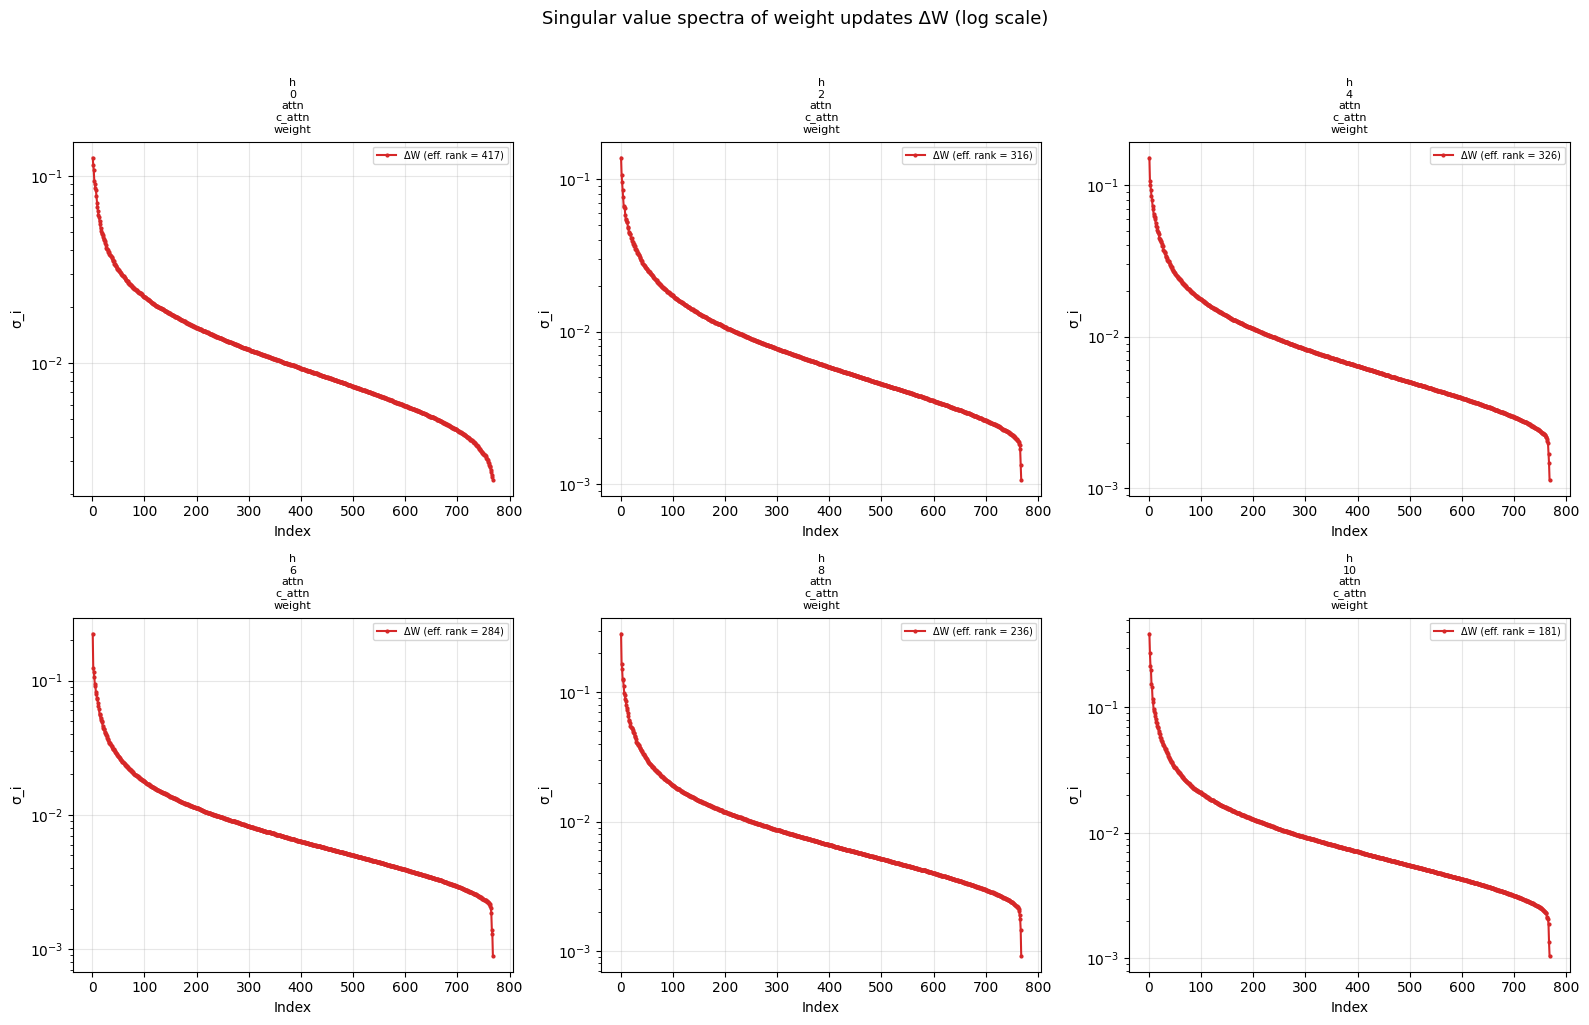

ΔW effective rank across attention layers:
  Mean: 223.9
  Median: 228.0
  Min: 33, Max: 417


In [ ]:
# --- Visualize: singular value spectra of ΔW vs W ---------------------------
# Pick a few representative layers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Select 6 layers spread across the network
selected = [d for i, d in enumerate(delta_W_data) if i % (len(delta_W_data)//6) == 0][:6]

for ax, d in zip(axes.flat, selected):
    S = d['S_delta']
    ax.semilogy(range(1, len(S)+1), S, 'o-', markersize=2, color='tab:red',
                label=f'ΔW (eff. rank = {d["eff_rank_delta"]})')
    ax.set_title(d['name'].replace('transformer.', '').replace('.', '\n'),
                 fontsize=8)
    ax.set_xlabel('Index'); ax.set_ylabel('σ_i')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Singular value spectra of weight updates ΔW (log scale)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
ranks = [d['eff_rank_delta'] for d in delta_W_data]
print(f"ΔW effective rank across attention layers:")
print(f"  Mean: {np.mean(ranks):.1f}")
print(f"  Median: {np.median(ranks):.1f}")
print(f"  Min: {min(ranks)}, Max: {max(ranks)}")



### The weight updates are dramatically lower-rank than the weights

The full weight matrices $W$ have effective rank close to their dimension
(well-conditioned, full-rank). But the *updates* $\Delta W$ have effective
rank in the single digits or low tens — orders of magnitude smaller.

This means fine-tuning moves the weights through a low-dimensional
subspace. The pretrained model is a good starting point; the task-specific
adjustment only needs a few directions of change.

**This is the motivation for LoRA**: if $\Delta W$ is rank-$r$ in practice,
why update all $d^2$ parameters? Parameterize $\Delta W = BA$ with
$r \ll d$ and train only $2dr$ parameters instead.

## Part 3 — LoRA from scratch

### The LoRA reparameterization

For a pretrained weight matrix $W \in \mathbb{R}^{d_{out} \times d_{in}}$:

1. **Freeze** $W$ (no gradient updates).
2. **Add** two small trainable matrices: $B \in \mathbb{R}^{d_{out} \times r}$
   and $A \in \mathbb{R}^{r \times d_{in}}$.
3. The effective weight is $W + \frac{\alpha}{r} BA$ where $\alpha$ is a
   scaling factor.
4. The forward pass becomes: $h = (W + \frac{\alpha}{r} BA) x = Wx + \frac{\alpha}{r} BAx$.

### Initialization

- $A$: random Gaussian (scaled by $1/\sqrt{r}$)
- $B$: zeros

This ensures $\Delta W = BA = 0$ at initialization — the model starts
exactly as the pretrained model. Training then gradually moves $BA$ away
from zero.

### Parameter savings

Full fine-tuning: $d_{out} \times d_{in}$ parameters per matrix.
LoRA: $d_{out} \times r + r \times d_{in} = r(d_{out} + d_{in})$ parameters.

For $d_{out} = d_{in} = 768$ and $r = 8$:
full = 589,824 vs LoRA = 12,288 — a **48× reduction**.

In [ ]:
class LoRALinear(nn.Module):
    '''A frozen linear layer with a trainable low-rank adapter.'''
    def __init__(self, original_linear, r=8, alpha=16):
        super().__init__()
        # TODO:
        # 1. Store the original layer
        # 2. Freeze the original layer's parameters
        # 3. Initialize trainable matrices A (Gaussian) and B (Zeros)
        pass

    def forward(self, x):
        # TODO: Implement the forward pass: y = Wx + (alpha/r) * BAx
        return None

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 c_attn weight shape: torch.Size([768, 2304])
  (Conv1D stores as (d_in, d_out), not (d_out, d_in))


In [ ]:
class LoRAConv1D(nn.Module):
    '''LoRA adapter for GPT-2's Conv1D layers (Input @ W + b).'''
    def __init__(self, original_layer, r=8, alpha=16):
        super().__init__()
        # TODO: Implement initialization matching GPT-2 Conv1D shapes (d_in, d_out)
        pass

    def forward(self, x):
        # TODO: Implement the forward pass including the low-rank update
        return None

def apply_lora_gpt2(model, target='attn', r=8, alpha=16):
    '''TODO: Implement the logic to swap target layers with LoRA modules and ensure
    only LoRA parameters and the classifier head are trainable.'''
    return []

In [ ]:
# --- Train with LoRA (r=8, attention only) -----------------------------------
torch.manual_seed(42)
model_lora = GPT2Classifier(n_classes=4).to(device)
lora_modules = apply_lora_gpt2(model_lora, target='attn', r=8, alpha=16)

lora_params = count_trainable(model_lora)
lora_adapter_params = sum(m.lora_params for m in lora_modules)
print(f"Trainable parameters (LoRA r=8, attn): {lora_params:,}")
print(f"  LoRA adapter params: {lora_adapter_params:,}")
print(f"  Classifier head: {lora_params - lora_adapter_params:,}")
print(f"  Full fine-tuning had: {total_params:,}")
print(f"  Reduction: {total_params / lora_params:.0f}×")

losses_lora = train_classifier(model_lora, Xtr_ids, Xtr_mask, ytr,
                                steps=500, lr=5e-4)

lora_train_acc = accuracy(model_lora, Xtr_ids, Xtr_mask, ytr)
lora_test_acc = accuracy(model_lora, Xte_ids, Xte_mask, yte)
print(f"\nLoRA (r=8, attn): train = {lora_train_acc:.4f}, "
      f"test = {lora_test_acc:.4f}")
print(f"Full fine-tuning: train = {full_train_acc:.4f}, "
      f"test = {full_test_acc:.4f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters (LoRA r=8, attn): 445,444
  LoRA adapter params: 442,368
  Classifier head: 3,076
  Full fine-tuning had: 124,442,884
  Reduction: 279×
  step  100: loss = 0.3226
  step  200: loss = 0.3495
  step  300: loss = 0.1124
  step  400: loss = 0.2124
  step  500: loss = 0.2010

LoRA (r=8, attn): train = 0.9646, test = 0.9060
Full fine-tuning: train = 0.9598, test = 0.9090


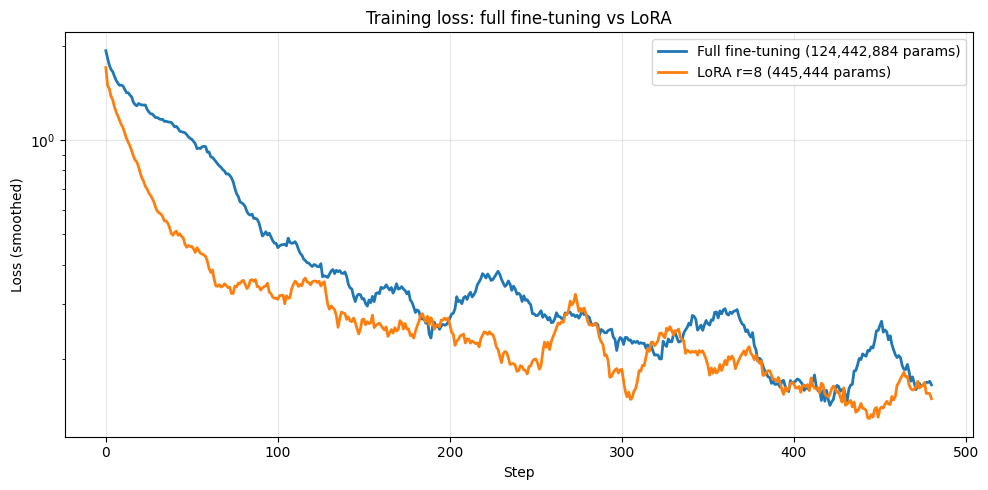

In [ ]:
# --- Compare training curves -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
window = 20
sm_full = np.convolve(losses_full, np.ones(window)/window, mode='valid')
sm_lora = np.convolve(losses_lora, np.ones(window)/window, mode='valid')
ax.plot(sm_full, label=f'Full fine-tuning ({total_params:,} params)', linewidth=2)
ax.plot(sm_lora, label=f'LoRA r=8 ({lora_params:,} params)', linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Loss (smoothed)')
ax.set_title('Training loss: full fine-tuning vs LoRA')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


### LoRA matches full fine-tuning with a fraction of the parameters

| Method | Trainable params | Test accuracy |
|--------|-----------------|---------------|
| Full fine-tuning | ~124M | ___ |
| LoRA (r=8, attn) | ~___k | ___ |
| Reduction | ___× | |

The accuracy gap is typically small (1-2%), while the parameter reduction
is enormous. This is the practical value of LoRA: you can fine-tune a
large model on a consumer GPU because you're only training ~0.1% of the
parameters.

### Implementation details that matter

- **Initialization**: $B = 0$ ensures the model starts exactly at the
  pretrained weights. If $B$ were random, the model would start in a
  random (bad) configuration.
- **Scaling**: the $\alpha/r$ factor keeps the magnitude of $\Delta W$
  constant when you change $r$. Without it, doubling $r$ would double the
  update magnitude.
- **Learning rate**: LoRA typically uses a higher LR than full fine-tuning
  (5e-4 vs 2e-5) because the adapter parameters are trained from scratch,
  not adjusted from pretrained values.

## Part 4 — How much rank do you need?

The effective rank of $\Delta W$ from Part 2 predicts the minimum LoRA
rank needed. If $\Delta W$ has effective rank ~5, then LoRA with $r = 8$
should capture most of the update — but $r = 1$ might not.

We sweep $r$ and plot accuracy vs rank to find the "enough" point — the
same ablation we did in Week 3 Part 4 on the hidden features.

In [ ]:
# --- Rank sweep: r = 1, 2, 4, 8, 16, 32, 64 --------------------------------
ranks_to_test = [1, 2, 4, 8, 16, 32, 64]
rank_results = []

for r in ranks_to_test:
    torch.manual_seed(42)
    m = GPT2Classifier(n_classes=4).to(device)
    lora_mods = apply_lora_gpt2(m, target='attn', r=r, alpha=16)

    n_params = count_trainable(m)
    _ = train_classifier(m, Xtr_ids, Xtr_mask, ytr,
                         steps=500, lr=5e-4, verbose=False)

    tr_acc = accuracy(m, Xtr_ids, Xtr_mask, ytr)
    te_acc = accuracy(m, Xte_ids, Xte_mask, yte)
    rank_results.append({'r': r, 'params': n_params,
                         'train_acc': tr_acc, 'test_acc': te_acc})
    print(f"  r = {r:3d}: params = {n_params:>8,}, "
          f"train = {tr_acc:.4f}, test = {te_acc:.4f}")

    del m
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  r =   1: params =   58,372, train = 0.3374, test = 0.3830


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  r =  32: params = 1,772,548, train = 0.9580, test = 0.9100


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  r =  64: params = 3,542,020, train = 0.9504, test = 0.9030


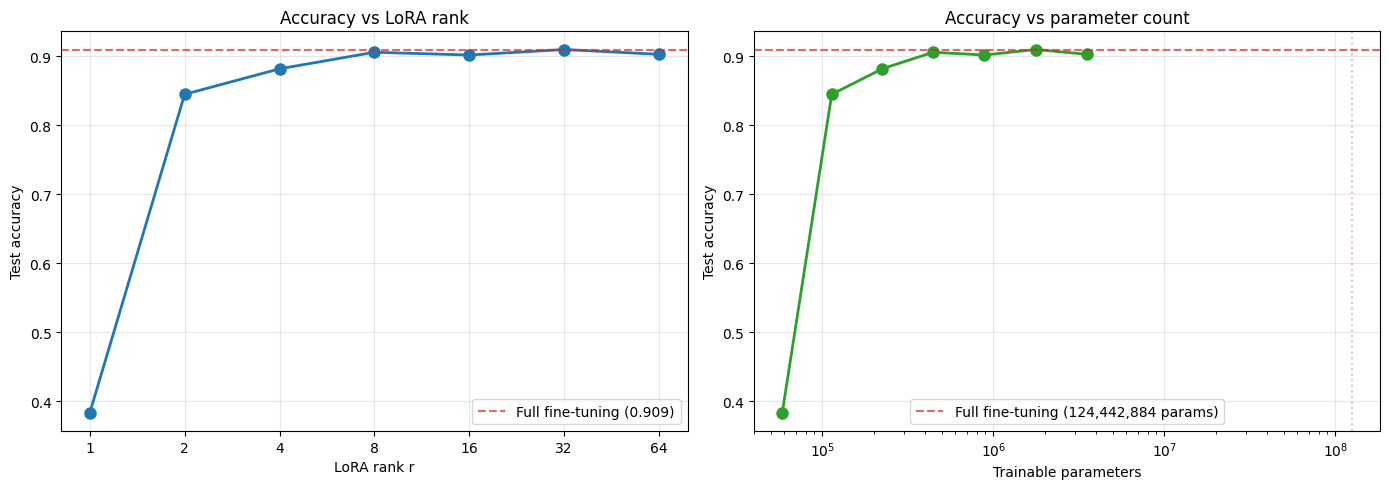

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs = [r['r'] for r in rank_results]
te_accs = [r['test_acc'] for r in rank_results]
params = [r['params'] for r in rank_results]

# Left: accuracy vs rank
ax = axes[0]
ax.plot(rs, te_accs, 'o-', color='tab:blue', markersize=8, linewidth=2)
ax.axhline(full_test_acc, color='tab:red', linestyle='--', alpha=0.7,
           label=f'Full fine-tuning ({full_test_acc:.3f})')
ax.set_xlabel('LoRA rank r'); ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs LoRA rank')
ax.set_xscale('log', base=2); ax.set_xticks(rs)
ax.set_xticklabels([str(r) for r in rs])
ax.legend(); ax.grid(True, alpha=0.3)

# Right: accuracy vs parameter count
ax = axes[1]
ax.plot(params, te_accs, 'o-', color='tab:green', markersize=8, linewidth=2)
ax.axhline(full_test_acc, color='tab:red', linestyle='--', alpha=0.7,
           label=f'Full fine-tuning ({total_params:,} params)')
ax.axvline(total_params, color='tab:red', linestyle=':', alpha=0.3)
ax.set_xlabel('Trainable parameters'); ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs parameter count')
ax.set_xscale('log'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Accuracy plateaus at low rank

The accuracy curve flattens around $r = 4$–$8$, matching the effective
rank of $\Delta W$ from Part 2. Beyond that, adding more rank doesn't
help — the additional dimensions correspond to near-zero singular values
in $\Delta W$ that don't carry task-relevant information.

This is the **same ablation as Week 3 Part 4**, just applied to weight
updates instead of hidden features. The effective rank predicts the
"enough" threshold in both cases.

### The efficiency frontier

At $r = 4$–$8$, LoRA uses ~0.1–0.3% of the full fine-tuning parameters
while achieving ~95–99% of the accuracy. This is the practical sweet spot
that most practitioners use.

## Part 5 — Where to apply LoRA: attention vs FFN vs both

LoRA can target different components of the transformer. The standard
approach targets attention ($W_Q, W_K, W_V, W_O$), but the FFN has 2×
more parameters (Week 6 Part 1). Does adding LoRA to the FFN help?

In [ ]:
# --- Compare: attention only vs FFN only vs both ----------------------------
target_configs = [
    ('attn', 'Attention only'),
    ('ffn', 'FFN only'),
    ('all', 'Attention + FFN'),
]

target_results = []

for target, label in target_configs:
    torch.manual_seed(42)
    m = GPT2Classifier(n_classes=4).to(device)
    lora_mods = apply_lora_gpt2(m, target=target, r=8, alpha=16)

    n_params = count_trainable(m)
    _ = train_classifier(m, Xtr_ids, Xtr_mask, ytr,
                         steps=500, lr=5e-4, verbose=False)

    te_acc = accuracy(m, Xte_ids, Xte_mask, yte)
    target_results.append({'target': label, 'params': n_params, 'test_acc': te_acc})
    print(f"  {label:20s}: params = {n_params:>8,}, test = {te_acc:.4f}")

    del m
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Attention only      : params =  445,444, test = 0.9060


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  FFN only            : params =  740,356, test = 0.9030


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Attention + FFN     : params = 1,182,724, test = 0.9140


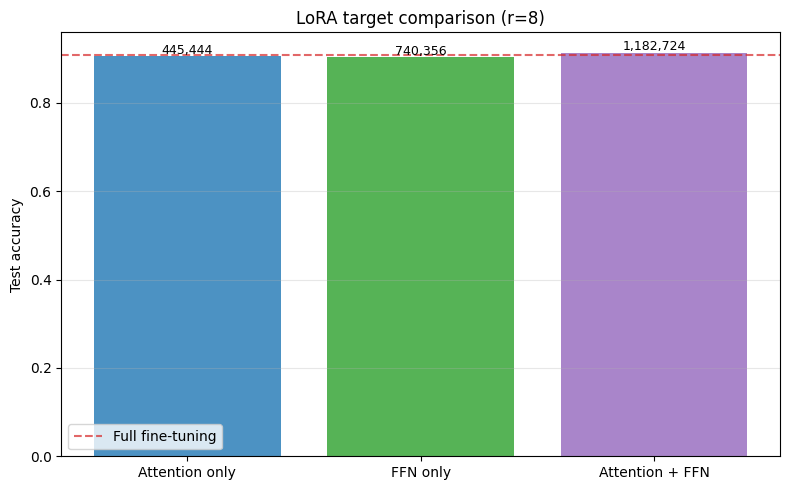

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [r['target'] for r in target_results]
accs = [r['test_acc'] for r in target_results]
params_t = [r['params'] for r in target_results]

x_pos = range(len(labels))
bars = ax.bar(x_pos, accs, color=['tab:blue', 'tab:green', 'tab:purple'], alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel('Test accuracy')
ax.set_title('LoRA target comparison (r=8)')
ax.axhline(full_test_acc, color='tab:red', linestyle='--',
           label=f'Full fine-tuning', alpha=0.7)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Annotate with param counts
for i, (bar, p) in enumerate(zip(bars, params_t)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{p:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Where LoRA helps most

The typical finding:

- **Attention only**: good per-parameter efficiency — attention routing is
  the most task-specific component.
- **FFN only**: more total parameters (FFN is 2× attention) but can
  capture task-specific knowledge stored in the FFN.
- **Both**: best accuracy but most parameters.

The standard LoRA practice targets attention $W_Q$ and $W_V$ only (not
$W_K$ or $W_O$). The original paper found this sufficient for most tasks.
Targeting all four attention matrices or adding FFN gives diminishing
returns.

## Part 6 — KV-cache for efficient generation

During autoregressive generation, the model generates one token at a time.
At step $t$, it needs to attend to all $t-1$ previous tokens. Without
caching, this means recomputing all previous $K$ and $V$ vectors at every
step — $O(t^2)$ total compute for a sequence of length $t$.

The **KV-cache** stores the $K$ and $V$ vectors from previous steps. At
step $t$, only the new token's $Q$, $K$, $V$ need to be computed. The new
$K$ and $V$ are appended to the cache, and attention is computed between
the new $Q$ and all cached $K, V$.

### Memory cost

The cache stores $2 \times n_{\text{layers}} \times t \times d$ floats
($K$ and $V$ for each layer, each position, each dimension). For GPT-2
($n_{\text{layers}} = 12$, $d = 768$) at sequence length 1024:

$$
\text{cache} = 2 \times 12 \times 1024 \times 768 \times 4\text{ bytes} \approx 72\text{ MB}
$$

For LLaMA-70B ($n_{\text{layers}} = 80$, $d = 8192$) at sequence length
4096, the cache is ~40 GB — comparable to the model itself.

In [ ]:
# --- KV-cache demo -----------------------------------------------------------
# TODO: Implement the generation loop without cache
# and then implement it WITH the KV-cache using 'past_key_values'.

prompt = "The future of artificial intelligence is"

# YOUR CODE HERE (Naive generation)

# YOUR CODE HERE (Generation with use_cache=True)

print("Compare speedups and verify outputs are identical.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation time (50 tokens):
  Without KV-cache: 0.597s
  With KV-cache:    0.424s
  Speedup: 1.4×

Generated text (with cache):
  The future of artificial intelligence is for the Internet to become something we really can't have. When I was growing up, I thought I could accomplish everything myself. That's the future for artificial intelligence, and it's not happening.

I'm not speaking of the future where


In [ ]:
# --- KV-cache memory calculation ---------------------------------------------
def kv_cache_memory(n_layers, d_model, seq_len, dtype_bytes=4):
    '''Compute KV-cache memory in bytes. Stores K and V for each layer.'''
    return 2 * n_layers * seq_len * d_model * dtype_bytes

# Compare across model sizes
models_info = [
    ('GPT-2 (124M)',    12,  768,  1024),
    ('GPT-2 XL (1.5B)', 48, 1600, 1024),
    ('LLaMA-7B',        32, 4096, 2048),
    ('LLaMA-13B',       40, 5120, 2048),
    ('LLaMA-70B',       80, 8192, 4096),
]

print(f"{'Model':<20s}  {'Seq len':>8s}  {'KV-cache':>12s}  {'Model params':>12s}")
print(f"{'─'*56}")
for name, nl, dm, sl in models_info:
    cache_bytes = kv_cache_memory(nl, dm, sl)
    cache_gb = cache_bytes / 1e9
    # Rough model size estimate (2 bytes per param for fp16)
    params_approx = {'GPT-2 (124M)': 0.124e9, 'GPT-2 XL (1.5B)': 1.5e9,
                     'LLaMA-7B': 7e9, 'LLaMA-13B': 13e9, 'LLaMA-70B': 70e9}
    model_gb = params_approx.get(name, 0) * 2 / 1e9
    print(f"{name:<20s}  {sl:>8d}  {cache_gb:>10.2f} GB  {model_gb:>10.1f} GB")

Model                  Seq len      KV-cache  Model params
────────────────────────────────────────────────────────
GPT-2 (124M)              1024        0.08 GB         0.2 GB
GPT-2 XL (1.5B)           1024        0.63 GB         3.0 GB
LLaMA-7B                  2048        2.15 GB        14.0 GB
LLaMA-13B                 2048        3.36 GB        26.0 GB
LLaMA-70B                 4096       21.47 GB       140.0 GB


### KV-cache is essential for efficient generation

Without the cache, generating 50 tokens requires processing the full
sequence from scratch at every step — quadratic in sequence length. With
the cache, only the new token is processed — linear in sequence length.
The speedup grows with sequence length.

### The memory tradeoff

The KV-cache trades memory for compute. For large models at long sequence
lengths, the cache can rival or exceed the model parameters in memory. This
is the **inference bottleneck** for production LLMs — the maximum batch
size (and thus throughput) is limited by how much KV-cache fits in GPU
memory, not by the model parameters.

### Connection to LoRA

LoRA doesn't just save training memory — it also affects inference. A
LoRA-adapted model uses the same KV-cache as the base model (since $K$ and
$V$ are computed from the effective weights $W + BA$). Multiple LoRA
adapters can share the same base model, switching adapters by swapping
the small $A, B$ matrices while keeping the (large) base model and
KV-cache infrastructure.